### 工作進度  
* 新的筆記架構仍待定。初步構想於下：
  - 盤前？
    * 近期股票老師沒有「盤前快訊」，因此這部份待檢討。
  - 第一部分：大盤解盤  
    * 『加權指數』與『櫃買指數』  
      - 補充老師盤中資訊。  
      - 對照老師的「盤前快訊」。  
  - 第二部分：個股解盤  
    * **選股**  
      - 老師觀察股  
      - 自選觀察股  
    * 補充籌碼面資訊：不是所有市場都有籌碼面資訊，因此很難透過AI進行分析，只能人工進行確認。
* 在量化投資分析系統(mysys)中加入公用函式模組(Utilities)，並把昨天(7月9日)開發的畫線程序整合進來。

#### 引入模組與定義公用函式  

In [1]:
import numpy as np
import mysys
import markdown
import base64
from IPython.core.display import HTML

In [2]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if buttom_pattern is True and '底部型態' in images :
        print('底型反轉交易策略：')
        display(images['底部型態'])
    print('解盤內容：')
    if '整體評價' in images :
        display(images['整體評價'])
    result_md   = results.to_markdown(tablefmt="grid")
    result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
    display(HTML(result_html))

#### 建立「解盤」物件    

In [3]:
analysis = mysys.StockAnalysis()

### 指數解盤  

* 加權指數

解盤內容：


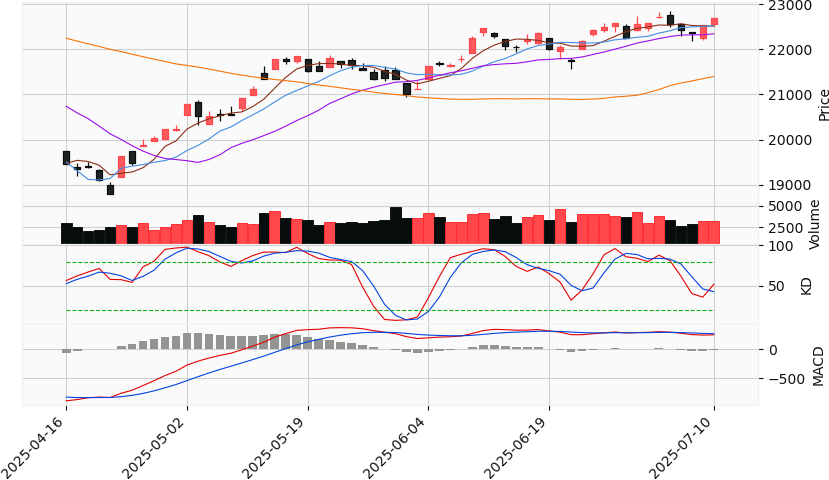

技術分析工具,解盤內容
Ｋ線／Ｋ棒,"十字線 : 2025-07-08 吞噬 : 2025-07-04 , 2025-07-09"
Ｋ線圖,中期為高位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 3273.94億元 ，十日均量 ＝ 3383.69億元）
型態,反轉型態之三重頂，型態範圍由2024-08-12開始到2025-03-03結束，估算目標價為21371.24。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為22257.56。
移動平均線,5日線下彎、10日線上揚，短期盤整；20日線上揚、60日線上揚，中期翻多；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-23當周黃金交叉。並且2025-06-30該周在超買區。
整體評價,根據圖表進行技術分析如下： 價格趨勢 近期價格呈現上漲趨勢，K線多為紅K，顯示多頭力量較強。短期移動平均線（5日、10日）均在中期移動平均線（20日、60日）之上，且呈現多頭排列，顯示上漲趨勢明顯。 價量關係 成交量在上漲時有所增加，顯示價量配合良好，支持上漲趨勢。近期成交量略有減少，需注意後續量能變化。 支撐與壓力 支撐位置可參考20日移動平均線附近，約在22000點左右。壓力位置則在近期高點附近，約在23000點。 KD指標解讀 KD指標顯示K線（紅線）在D線（藍線）之上，且從低位回升，顯示短期有反彈動能。指標值在50附近，尚未進入超買區，仍有上升空間。 MACD指標解讀 MACD指標中，DIF線（紅線）在MACD線（藍線）之上，且柱狀體為正值，顯示多頭趨勢持續。雖然柱狀體略有縮短，需注意後續變化。 綜合評價 整體來看，市場目前處於上漲趨勢，價量配合良好，短期內有望繼續上行。然而，需注意成交量的變化以及MACD柱狀體的縮短，可能預示著短期內的震盪或回檔風險。建議投資者可考慮在支撐位附近進行佈局，並設置適當的停損點以控制風險。


In [4]:
stock_analysis(analysis,'TAIEX')

加權指數還在上升楔形的整理中：  
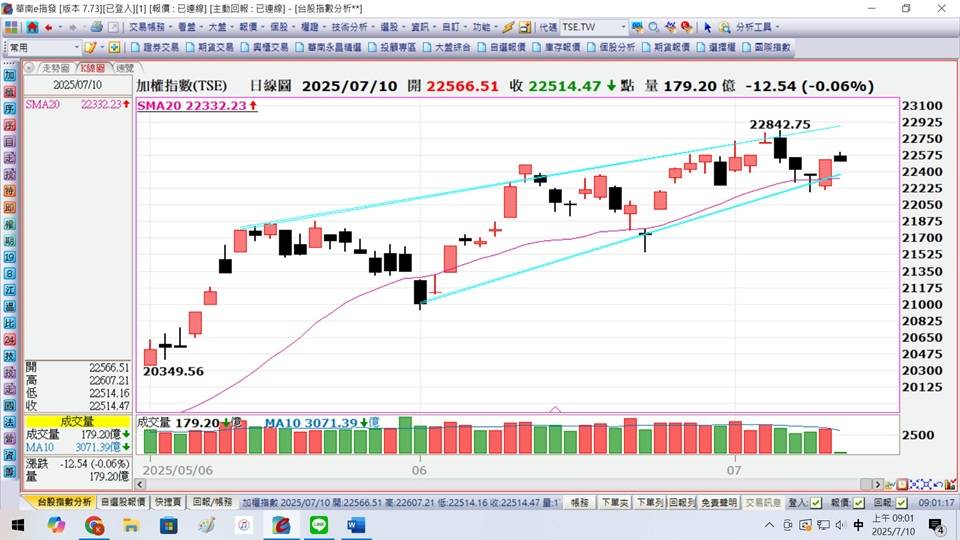  

In [5]:
def line_drawing_callback( range_prices) :
    # 設定楔形壓力線
    resistance_line_start_date  = '2025-05-14'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_x           = [mysys.DateToIndex(range_prices,'2025-05-16'),mysys.DateToIndex(range_prices,'2025-07-04')]
    resistance_line_y           = [range_prices.loc['2025-05-16']['Close'],range_prices.loc['2025-07-04']['Open']]
    slope,intercept             = np.polyfit(resistance_line_x,resistance_line_y,1)
    resistance_line_start_price = slope * mysys.DateToIndex(range_prices,resistance_line_start_date) + intercept
    resistance_line_end_price   = slope * mysys.DateToIndex(range_prices,resistance_line_end_date) + intercept

    # 設定楔形支撐線
    support_line_start_date  = '2025-06-02'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_x           = [mysys.DateToIndex(range_prices,'2025-06-02'),mysys.DateToIndex(range_prices,'2025-06-23')]
    support_line_y           = [range_prices.loc['2025-06-02']['Close'],range_prices.loc['2025-06-23']['Close']]
    slope,intercept          = np.polyfit(support_line_x,support_line_y,1)
    support_line_start_price = slope * mysys.DateToIndex(range_prices,support_line_start_date) + intercept
    support_line_end_price   = slope * mysys.DateToIndex(range_prices,support_line_end_date) + intercept

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_start_price),(resistance_line_end_date,resistance_line_end_price)],
        [(support_line_start_date,support_line_start_price),(support_line_end_date,support_line_end_price)]
    ]

    linewidths=[1.5,1.5]
    
    colors=['xkcd:cyan','xkcd:cyan']

    return seq_of_seq_of_points,linewidths,colors

In [6]:
image = mysys.DrawOnKlineChart('TAIEX','2025-05-06','2025-07-10',line_drawing_callback)

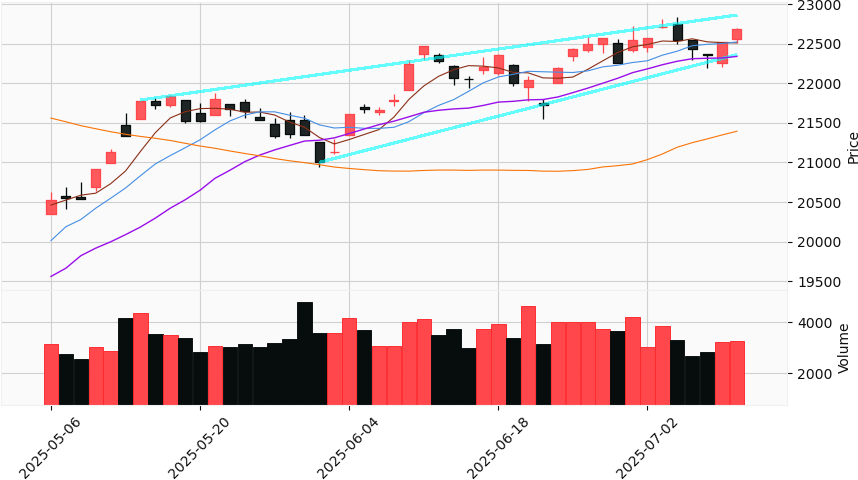

In [7]:
display(image)

* 櫃買指數

解盤內容：


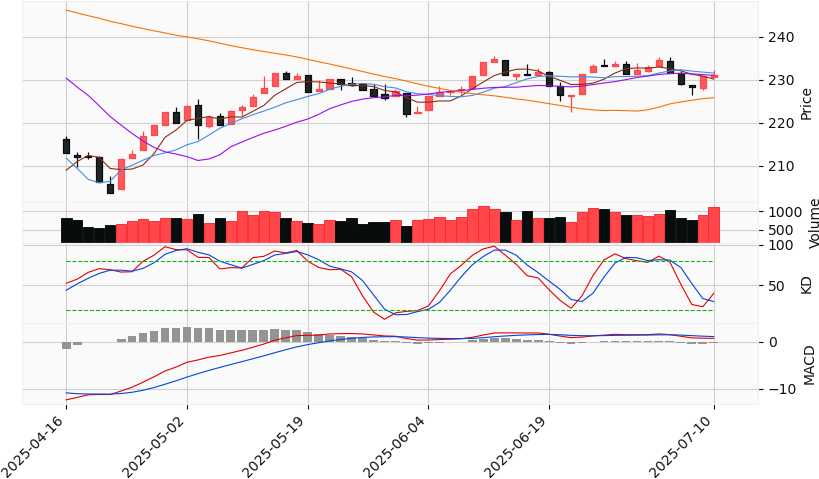

技術分析工具,解盤內容
Ｋ線／Ｋ棒,鎚子線／吊人線 : 2025-07-08 吞噬 : 2025-07-09
Ｋ線圖,中期為中位階 長期為中位階
成交量,價量關係：未至大量門檻（成交量 ＝ 1114.05億元 ，十日均量 ＝ 921.9億元）
型態,盤整型態之三角形，型態範圍由2024-07-11開始到2025-03-28結束。 底型反轉之底部型態，型態範圍由2025-04-02開始到2025-05-02結束，估算目標價為247.79。
移動平均線,5日線下彎、10日線下彎，短期翻空；20日線下彎、60日線上揚，中期盤整；120日線下彎、240日線下彎，長期翻空
ＫＤ指標,於2025-07-10黃金交叉。
ＭＡＣＤ指標,MACD在零軸以上，中期多方
周Ｋ－周ＫＤ指標,於2025-06-02當周死亡交叉。
整體評價,價格趨勢分析 目前價格呈現盤整狀態。K線圖顯示價格在230點附近波動，短期移動平均線（5日、10日）與中期移動平均線（20日、60日）糾結，顯示出市場缺乏明確方向。 價量關係 成交量在近期有增加的趨勢，但價格並未隨之大幅波動，顯示出多空雙方力量相對均衡，市場觀望情緒較重。 支撐與壓力判斷 支撐位置大約在220點，壓力位置則在240點。價格在這兩個區間內波動，若突破其中一個位置，可能會出現較明顯的趨勢。 KD指標解讀 KD指標顯示K線與D線在低檔區域交叉向上，從超賣區回升，這可能預示著短期內有反彈的機會。 MACD指標解讀 MACD指標中，DIF線與MACD線接近零軸，且柱狀體顯示出動能減弱，這表明市場目前缺乏明顯的趨勢動能。 綜合評價 整體來看，市場目前處於盤整階段，短期內可能會有小幅反彈，但缺乏強勁的趨勢動能。建議投資者謹慎觀望，等待價格突破支撐或壓力位置後再行操作。若價格突破240點，可能會有進一步上漲的空間；若跌破220點，則需考慮停損。


In [8]:
stock_analysis(analysis,'TPEx')

櫃買指數持續盤整：  
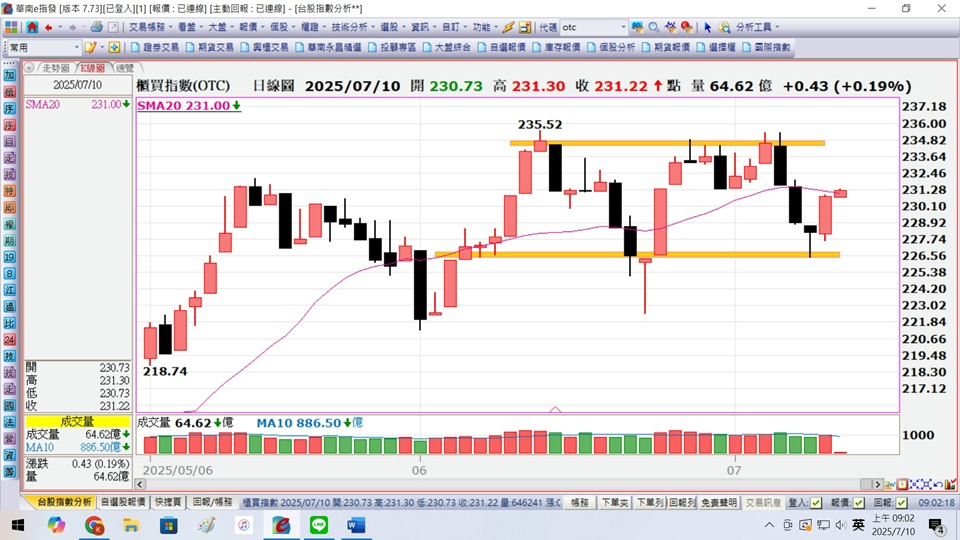  

In [9]:
def line_drawing_callback( range_prices) :
    # 設定箱型壓力線
    resistance_line_start_date  = '2025-06-09'
    resistance_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    resistance_line_price       = range_prices.loc['2025-06-12']['Close']

    # 設定楔形支撐線
    support_line_start_date  = '2025-06-03'
    support_line_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    support_line_price       = range_prices.loc['2025-06-20']['Close']

    seq_of_seq_of_points=[
        [(resistance_line_start_date,resistance_line_price),(resistance_line_end_date,resistance_line_price)],
        [(support_line_start_date,support_line_price),(support_line_end_date,support_line_price)]
    ]

    linewidths=[2.5,2.5]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow']

    return seq_of_seq_of_points,linewidths,colors

In [10]:
image = mysys.DrawOnKlineChart('TPEx','2025-05-06','2025-07-10',line_drawing_callback)

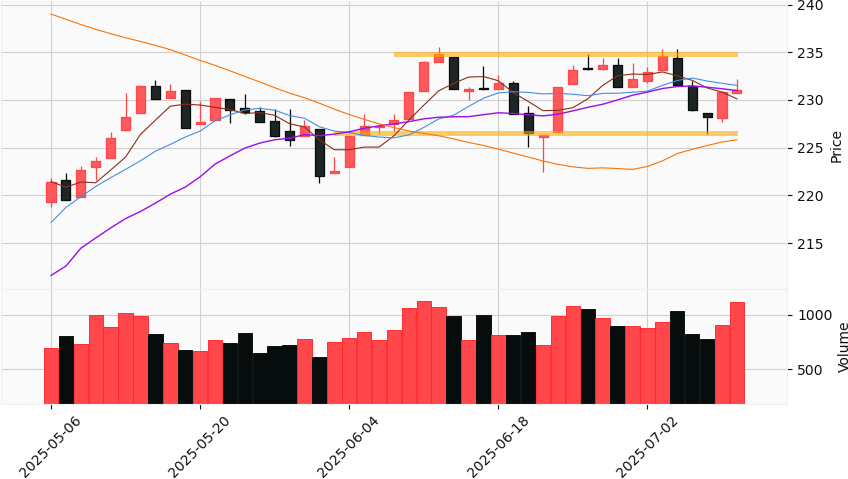

In [11]:
display(image)